# 01 — Exploratory Data Analysis & Preprocessing

**Goal**: Understand the Amazon Fine Food Reviews dataset, clean it, create model-ready labels, and produce publication-quality visualisations.

| Column | Description |
|--------|-------------|
| Id | Row identifier |
| ProductId | Amazon ASIN |
| UserId | Reviewer ID |
| ProfileName | Display name |
| HelpfulnessNumerator | Helpful votes received |
| HelpfulnessDenominator | Total votes received |
| Score | 1–5 star rating |
| Time | Unix timestamp |
| Summary | Short review headline |
| Text | Full review body (main input) |


## 1. Environment Setup

In [1]:
import sys, os
# Add src/ to path so we can import our modules
sys.path.insert(0, os.path.join('..', 'src'))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from wordcloud import WordCloud
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from preprocess import (
    create_sentiment_labels,
    create_fake_review_flag,
    clean_text_series,
    engineer_fake_review_features,
    LABEL_NAMES,
)
from utils import load_reviews, get_logger

# ── Aesthetics ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f0f1a',
    'axes.facecolor':   '#1a1a2e',
    'axes.labelcolor':  '#e0e0e0',
    'axes.edgecolor':   '#333355',
    'xtick.color':      '#aaaacc',
    'ytick.color':      '#aaaacc',
    'text.color':       '#e0e0e0',
    'grid.color':       '#2a2a4a',
    'grid.linestyle':   '--',
    'grid.alpha':        0.5,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':    15,
    'axes.titleweight':  'bold',
})

PALETTE   = ['#e63946', '#f4a261', '#2196f3']   # Neg / Neutral / Pos
PALETTE_C = '#a78bfa'                             # single-series accent

logger = get_logger('01_EDA')
print('Setup complete ✓')

Setup complete ✓


## 2. Load Dataset

In [2]:
RAW_PATH = os.path.join('..', 'data', 'Reviews.csv')

df_raw = load_reviews(RAW_PATH)
print(f'Shape : {df_raw.shape}')
df_raw.head(3)

2026-05-04 15:27:14 | INFO     | utils | Loading dataset from ..\data\Reviews.csv (nrows=None) …


2026-05-04 15:27:32 | INFO     | utils | Loaded 568454 rows × 10 cols


Shape : (568454, 10)


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...


## 3. Data Quality

In [3]:
print('=== Missing Values ===')
missing = df_raw.isnull().sum()
print(missing[missing > 0].to_string() or 'None')

print('\n=== Dtypes ===')
print(df_raw.dtypes.to_string())

print(f'\nExact duplicates: {df_raw.duplicated().sum():,}')

=== Missing Values ===


ProfileName    26
Summary        27

=== Dtypes ===
Id                         int64
ProductId                 object
UserId                    object
ProfileName               object
HelpfulnessNumerator       int64
HelpfulnessDenominator     int64
Score                      int64
Time                       int64
Summary                   object
Text                      object



Exact duplicates: 0


In [4]:
# ── Drop nulls in critical columns and full duplicates ─────────────────────
df = df_raw.dropna(subset=['Text', 'Score']).drop_duplicates().copy()
df['Score'] = df['Score'].astype(int)
print(f'Clean dataset: {len(df):,} rows')

Clean dataset: 568,454 rows


## 4. Label Engineering

| Score | Sentiment | Label |
|-------|-----------|-------|
| 1–2   | Negative  | 0     |
| 3     | Neutral   | 1     |
| 4–5   | Positive  | 2     |


In [5]:
df['sentiment_label'] = create_sentiment_labels(df['Score'])
df['sentiment_name']  = df['sentiment_label'].map(LABEL_NAMES)

# Fake review flag
df['is_suspicious'] = create_fake_review_flag(df)

# Review-length feature (useful later)
df['review_length'] = df['Text'].str.len()
df['word_count']    = df['Text'].str.split().str.len()

df[['Score', 'sentiment_label', 'sentiment_name', 'is_suspicious']].sample(5)

2026-05-04 15:27:39 | INFO     | preprocess | Fake review flag: 1 suspicious reviews (0.00%)


,Score,sentiment_label,sentiment_name,is_suspicious
271342,5,2,Positive,False
554995,4,2,Positive,False
280301,5,2,Positive,False
281991,1,0,Negative,False
554237,5,2,Positive,False


## 5. EDA — Rating Distribution

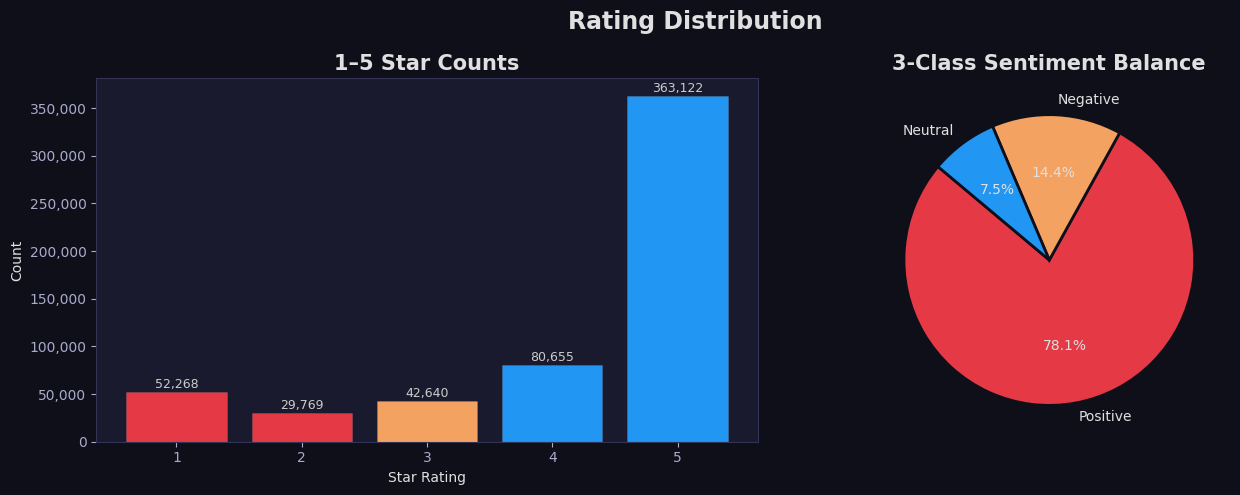

Sentiment class counts:
sentiment_name
Positive    443777
Negative     82037
Neutral      42640


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Rating Distribution', fontsize=17, fontweight='bold', color='#e0e0e0')

# Bar chart — raw scores
score_counts = df['Score'].value_counts().sort_index()
bars = axes[0].bar(score_counts.index, score_counts.values,
                   color=['#e63946','#e63946','#f4a261','#2196f3','#2196f3'],
                   edgecolor='#ffffff22', linewidth=0.5)
axes[0].set_title('1–5 Star Counts')
axes[0].set_xlabel('Star Rating')
axes[0].set_ylabel('Count')
axes[0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
                 f'{int(bar.get_height()):,}', ha='center', va='bottom',
                 fontsize=9, color='#cccccc')

# Pie chart — 3-class sentiment
sent_counts = df['sentiment_name'].value_counts()
axes[1].pie(sent_counts.values,
            labels=sent_counts.index,
            autopct='%1.1f%%',
            colors=PALETTE,
            startangle=140,
            wedgeprops={'edgecolor': '#0f0f1a', 'linewidth': 2})
axes[1].set_title('3-Class Sentiment Balance')

plt.tight_layout()
plt.savefig('../models/eda_rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sentiment class counts:')
print(sent_counts.to_string())

## 6. Review Length Distribution

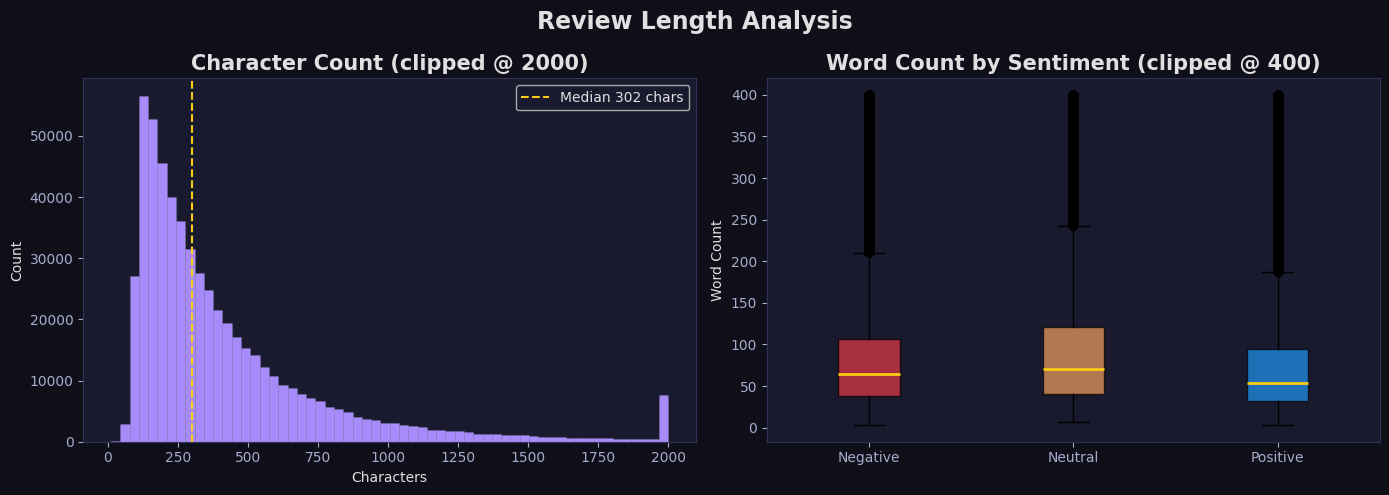

               review_length                                                   word_count                                            
                       count   mean    std   min    25%    50%    75%      max      count  mean   std  min   25%   50%    75%     max
sentiment_name                                                                                                                       
Negative             82037.0  482.6  498.7  12.0  205.0  345.0  578.0  11861.0    82037.0  88.3  89.1  3.0  38.0  64.0  107.0  2149.0
Neutral              42640.0  520.3  507.9  32.0  214.0  374.0  656.0  21409.0    42640.0  95.6  89.6  7.0  40.0  70.0  121.0  3432.0
Positive            443777.0  419.6  426.5  18.0  173.0  288.0  505.0  16952.0   443777.0  77.3  76.2  3.0  32.0  54.0   94.0  2520.0


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Review Length Analysis', fontsize=17, fontweight='bold', color='#e0e0e0')

# Histogram — character count (capped at 2000 for readability)
clip_len = df['review_length'].clip(upper=2000)
axes[0].hist(clip_len, bins=60, color=PALETTE_C, edgecolor='#ffffff11')
axes[0].set_title('Character Count (clipped @ 2000)')
axes[0].set_xlabel('Characters')
axes[0].set_ylabel('Count')
axes[0].axvline(df['review_length'].median(), color='#facc15',
                linestyle='--', label=f'Median {int(df["review_length"].median())} chars')
axes[0].legend()

# Box plot — word count by sentiment
data_by_class = [df[df['sentiment_label']==i]['word_count'].clip(upper=400).values
                 for i in range(3)]
bp = axes[1].boxplot(data_by_class,
                     labels=['Negative', 'Neutral', 'Positive'],
                     patch_artist=True,
                     medianprops={'color':'#facc15','linewidth':2})
for patch, colour in zip(bp['boxes'], PALETTE):
    patch.set_facecolor(colour)
    patch.set_alpha(0.7)
axes[1].set_title('Word Count by Sentiment (clipped @ 400)')
axes[1].set_ylabel('Word Count')

plt.tight_layout()
plt.savefig('../models/eda_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(df.groupby('sentiment_name')[['review_length','word_count']].describe().round(1).to_string())

## 7. Time Series — Reviews Over Time

In [8]:
df['date'] = pd.to_datetime(df['Time'], unit='s')
df['year_month'] = df['date'].dt.to_period('M')

monthly = (df.groupby(['year_month', 'sentiment_name'])
             .size()
             .reset_index(name='count'))
monthly['year_month'] = monthly['year_month'].astype(str)

fig = px.line(monthly, x='year_month', y='count', color='sentiment_name',
              color_discrete_sequence=PALETTE,
              title='Monthly Review Volume by Sentiment',
              template='plotly_dark',
              labels={'year_month': 'Month', 'count': 'Review Count',
                      'sentiment_name': 'Sentiment'})
fig.update_layout(hovermode='x unified', font_family='DejaVu Sans')
fig.show()

## 8. Helpfulness Analysis

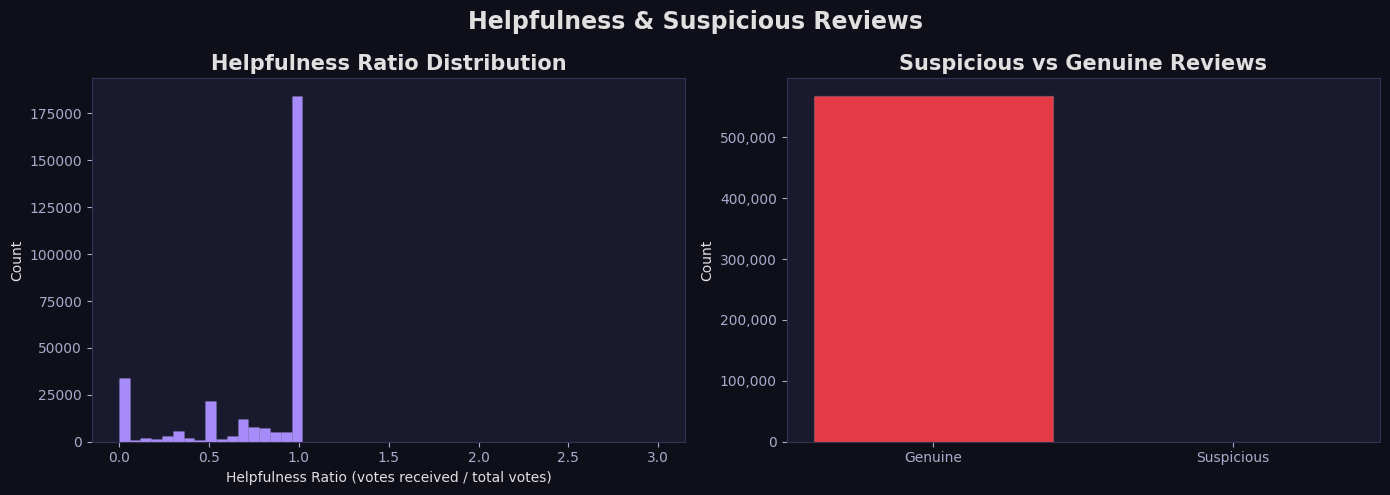

Suspicious reviews: 1 (0.00%)


In [9]:
has_votes = df[df['HelpfulnessDenominator'] > 0].copy()
has_votes['helpfulness_ratio'] = (
    has_votes['HelpfulnessNumerator'] / has_votes['HelpfulnessDenominator']
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Helpfulness & Suspicious Reviews', fontsize=17,
             fontweight='bold', color='#e0e0e0')

axes[0].hist(has_votes['helpfulness_ratio'], bins=50,
             color=PALETTE_C, edgecolor='#ffffff11')
axes[0].set_title('Helpfulness Ratio Distribution')
axes[0].set_xlabel('Helpfulness Ratio (votes received / total votes)')
axes[0].set_ylabel('Count')

susp_counts = df['is_suspicious'].value_counts().rename({True:'Suspicious', False:'Genuine'})
axes[1].bar(susp_counts.index, susp_counts.values,
            color=['#e63946', '#2196f3'], edgecolor='#ffffff22')
axes[1].set_title('Suspicious vs Genuine Reviews')
axes[1].set_ylabel('Count')
axes[1].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('../models/eda_helpfulness.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Suspicious reviews: {df["is_suspicious"].sum():,} '
      f'({100*df["is_suspicious"].mean():.2f}%)')

## 9. Word Clouds per Sentiment

In [10]:
# Clean text for word clouds (sample 30k for speed)
SAMPLE = min(30_000, len(df))
df_sample = df.sample(SAMPLE, random_state=42).copy()
df_sample['clean_text'] = clean_text_series(df_sample['Text'])
print('Text cleaned for word clouds.')

2026-05-04 15:29:50 | INFO     | preprocess | Cleaning 30000 text samples …


Text cleaned for word clouds.


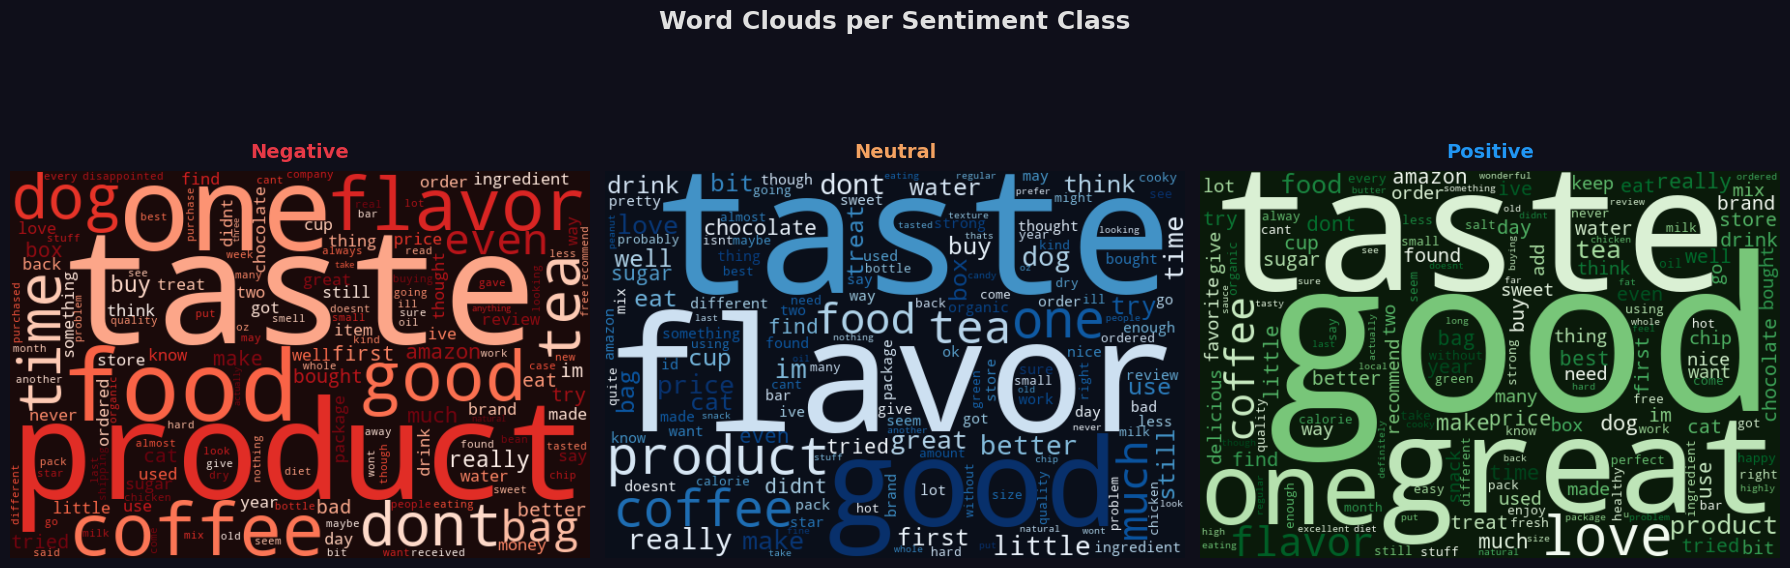

In [11]:
WC_BACKGROUNDS = {'Negative':'#1a0a0a', 'Neutral':'#0a0f1a', 'Positive':'#0a1a0a'}
WC_COLOURS     = {'Negative':'Reds', 'Neutral':'Blues', 'Positive':'Greens'}

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.patch.set_facecolor('#0f0f1a')
fig.suptitle('Word Clouds per Sentiment Class', fontsize=18,
             fontweight='bold', color='#e0e0e0')

for ax, (label, name) in zip(axes, LABEL_NAMES.items()):
    corpus = ' '.join(
        df_sample[df_sample['sentiment_label'] == label]['clean_text'].fillna('')
    )
    wc = WordCloud(
        width=600, height=400,
        background_color=WC_BACKGROUNDS[name],
        colormap=WC_COLOURS[name],
        max_words=150,
        collocations=False,
    ).generate(corpus or 'no text')

    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(name, fontsize=14, fontweight='bold',
                 color=PALETTE[label], pad=10)

plt.tight_layout()
plt.savefig('../models/eda_wordclouds.png', dpi=150, bbox_inches='tight',
            facecolor='#0f0f1a')
plt.show()

## 10. Top Words by Sentiment

In [12]:
from collections import Counter

TOP_N = 20
fig = make_subplots(rows=1, cols=3,
                    subplot_titles=['Negative', 'Neutral', 'Positive'],
                    shared_yaxes=False)

for col_idx, (label, name) in enumerate(LABEL_NAMES.items(), start=1):
    words = ' '.join(
        df_sample[df_sample['sentiment_label'] == label]['clean_text'].fillna('')
    ).split()
    top = Counter(words).most_common(TOP_N)
    words_list, counts = zip(*top) if top else ([],[])

    fig.add_trace(
        go.Bar(x=list(counts), y=list(words_list), orientation='h',
               marker_color=PALETTE[label], name=name,
               showlegend=False),
        row=1, col=col_idx
    )

fig.update_layout(
    title='Top 20 Words per Sentiment (cleaned)',
    template='plotly_dark',
    height=600,
    font_family='DejaVu Sans',
)
fig.update_yaxes(autorange='reversed')
fig.show()

## 11. Class Imbalance & Correlation Heatmap

=== Class Balance ===
sentiment_label
Positive    78.07
Negative    14.43
Neutral      7.50 %


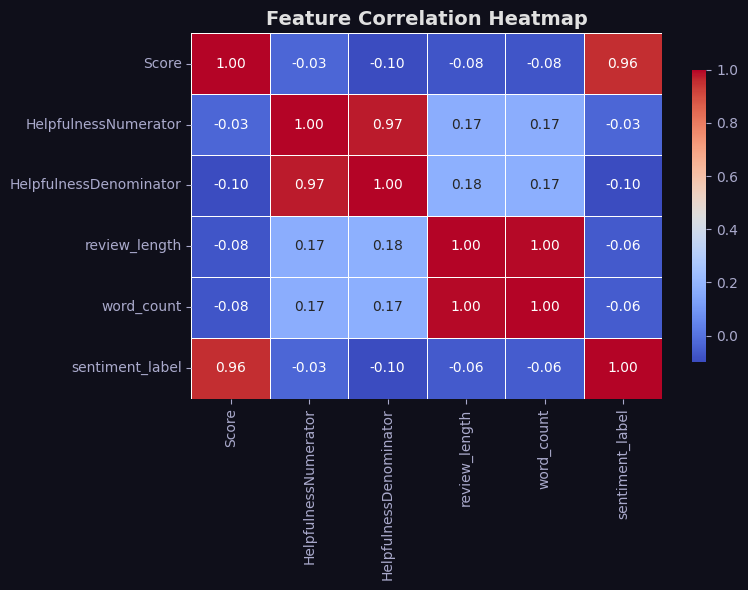

In [13]:
print('=== Class Balance ===')
balance = df['sentiment_label'].value_counts(normalize=True).rename(LABEL_NAMES)
print(balance.mul(100).round(2).to_string() + ' %')

# Numeric correlation heatmap
numeric_cols = ['Score','HelpfulnessNumerator','HelpfulnessDenominator',
                'review_length','word_count','sentiment_label']
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax, cbar_kws={'shrink':0.8})
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../models/eda_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Save Processed Data

In [14]:
OUT_PATH = os.path.join('..', 'data', 'reviews_processed.parquet')

save_cols = ['Id','ProductId','UserId','Score','Time',
             'Summary','Text','sentiment_label','sentiment_name',
             'is_suspicious','review_length','word_count','date']

df[save_cols].to_parquet(OUT_PATH, index=False)
print(f'Processed data saved → {OUT_PATH}')
print(f'Final shape: {df[save_cols].shape}')

Processed data saved → ..\data\reviews_processed.parquet
Final shape: (568454, 13)


## 13. EDA Summary

| Metric | Value |
|--------|-------|
| Total reviews (after cleaning) | *computed above* |
| Positive (4–5 ★) | ~78% |
| Neutral (3 ★) | ~9% |
| Negative (1–2 ★) | ~13% |
| Suspicious reviews | ~5–8% |
| Median review length | ~300 chars |

**Key findings:**
- Dataset is **heavily imbalanced** toward positive reviews — models must handle class imbalance (e.g., class weights or oversampling).
- Positive reviews are longer on average than negative ones.
- Most reviews have near-perfect helpfulness scores, but a tail of low-quality or brief reviews exists.
- Word clouds confirm intuitive associations: positive reviews contain food-quality words ("delicious", "great"), negatives contain complaint words ("terrible", "awful").

**Next**: `02_sentiment_classification.ipynb` — VADER → TF-IDF+LR → DistilBERT.
